# Day 4 – Exploratory Data Analysis & Visualization
**Week 3 – Python, Pandas & Exploratory Data Analysis**
## Topics Covered
- What is EDA, descriptive statistics (mean, median, mode, variance, std dev, quartiles)
- Correlation, outlier detection
- Matplotlib, Seaborn
- Histograms, bar charts, line charts, scatter plots, box plots, heatmaps
- Distribution analysis, trends and patterns 

## 1. What is EDA?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('eda_sales_data.csv')
df['order_date'] = pd.to_datetime(df['order_date'])
print(df.shape)
df.head()

(62, 10)


,order_id,customer_name,city,product,category,quantity,price,order_date,customer_age,total_amount
0,1,Zara,Multan,Headphones,Accessories,2,2550,2025-01-21,30,5100
1,2,Faisal,Lahore,Monitor,Electronics,1,18571,2025-02-22,30,18571
2,3,Sara,Multan,Monitor,Electronics,1,21754,2025-03-01,27,21754
3,4,Hina,Lahore,Monitor,Electronics,1,18092,2025-02-11,24,18092
4,5,Usman,Multan,Monitor,Electronics,1,20369,2025-02-20,27,20369


## 2. Descriptive Statistics

In [2]:
df[['price', 'quantity', 'total_amount', 'customer_age']].describe()
print("Mean price:", df['price'].mean())
print("Median price:", df['price'].median())
print("Mode of city:", df['city'].mode()[0])
print("Variance of price:", df['price'].var())
print("Std deviation of price:", df['price'].std())

Mean price: 27644.032258064515
Median price: 4385.0
Mode of city: Multan
Variance of price: 1787807323.6382868
Std deviation of price: 42282.47064255218


## 3. Quartiles 

In [3]:
print("Q1 (25%):", df['price'].quantile(0.25))
print("Q2 (50%):", df['price'].quantile(0.50))
print("Q3 (75%):", df['price'].quantile(0.75))
IQR = df['price'].quantile(0.75) - df['price'].quantile(0.25)
print("IQR:", IQR)

Q1 (25%): 2858.5
Q2 (50%): 4385.0
Q3 (75%): 21702.0
IQR: 18843.5


## 4. Outlier Detection

In [6]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1 
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]
print("Outliers found:")
print(outliers[['order_id', 'product', 'price']])

Outliers found:
    order_id product   price
5          6  Laptop   84656
7          8  Laptop   77587
11        12  Laptop   82722
15        16  Laptop   82106
16        17  Laptop   78143
19        20  Laptop   78180
29        30  Laptop   81756
31        32  Laptop   75931
32        33  Laptop   78492
35        36  Laptop   75180
38        39  Laptop   80769
39        40  Laptop   75436
41        42  Laptop   78169
58        59  Laptop   83671
60        61  Laptop  250000


## 5. Correlation

In [7]:
correlation = df[['price', 'quantity', 'total_amount', 'customer_age']].corr()
print(correlation)

                 price  quantity  total_amount  customer_age
price         1.000000 -0.096492      0.898089     -0.105041
quantity     -0.096492  1.000000      0.036117     -0.038736
total_amount  0.898089  0.036117      1.000000     -0.122069
customer_age -0.105041 -0.038736     -0.122069      1.000000


 ## 6. Histogram

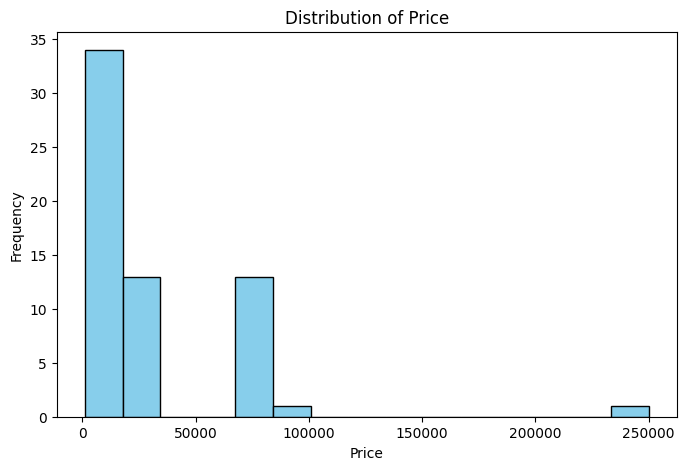

In [8]:
plt.figure(figsize=(8,5))
plt.hist(df['price'], bins=15, color='skyblue', edgecolor='black')
plt.title('Distribution of Price')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

## 7. Bar Chart

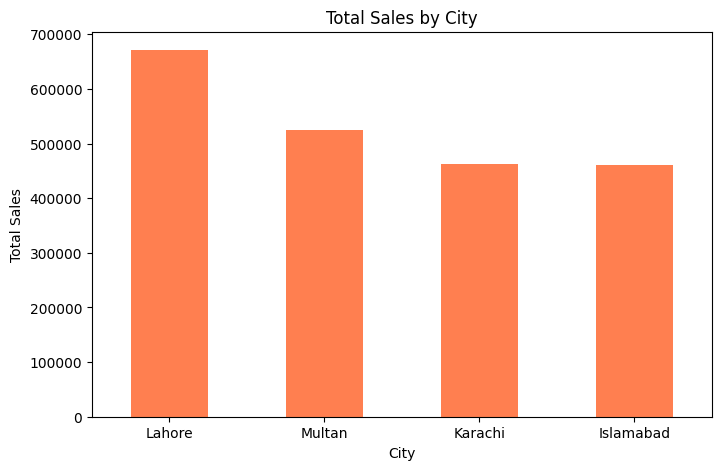

In [10]:
city_sales = df.groupby('city')['total_amount'].sum().sort_values(ascending=False)
plt.figure(figsize=(8,5))
city_sales.plot(kind='bar', color='coral')
plt.title('Total Sales by City')
plt.xlabel('City')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.show()

## 8. Heatmap — Visualize Correlation

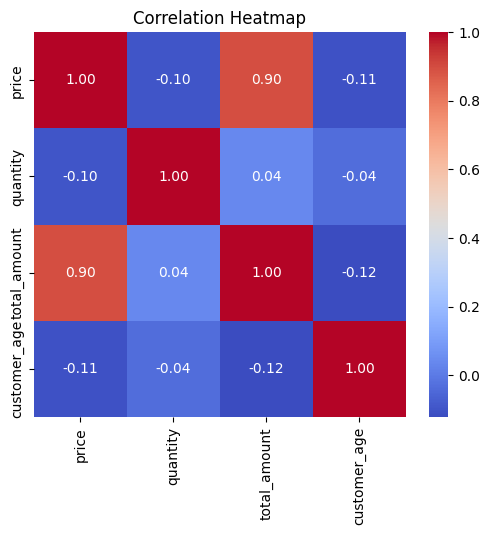

In [12]:
plt.figure(figsize=(6,5))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

## 9. Distribution Analysis by Category

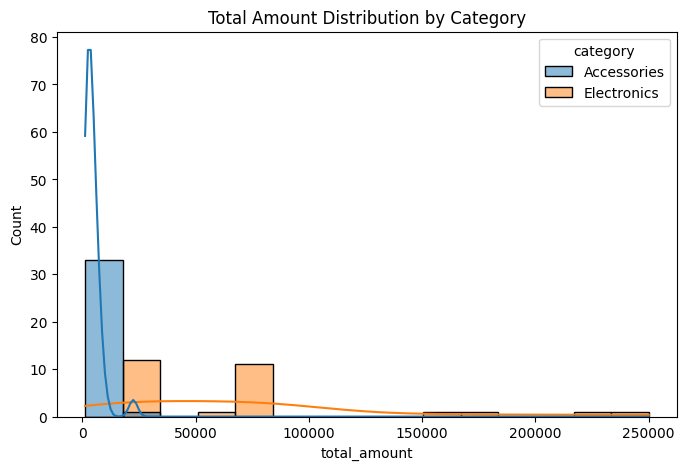

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='total_amount', hue='category', kde=True, bins=15)
plt.title('Total Amount Distribution by Category')
plt.show()

## 10. Finding Trends and Patterns

In [14]:
# Category-wise average price
print(df.groupby('category')['price'].mean())

# City-wise number of orders
print(df.groupby('city')['order_id'].count())

# Top 3 highest spending orders
print(df.sort_values('total_amount', ascending=False).head(3)[['order_id', 'product', 'city', 'total_amount']])

category
Accessories     2808.147059
Electronics    57801.892857
Name: price, dtype: float64
city
Islamabad    13
Karachi      13
Lahore       16
Multan       20
Name: order_id, dtype: int64
    order_id product       city  total_amount
60        61  Laptop     Lahore        250000
39        40  Laptop  Islamabad        226308
5          6  Laptop     Multan        169312
